In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from operator import add
import seaborn as sns

%matplotlib inline

In [7]:
df = pd.read_csv("heart.csv")

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [11]:
df['Age'].value_counts()
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

Label Encoding

In [12]:
categorical_cols= df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


In [13]:
for col in categorical_cols:
  print(col,df[col].unique())

Sex <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina <StringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [14]:
for col in categorical_cols:
    print(col, df[col].nunique())

Sex 2
ChestPainType 4
RestingECG 3
ExerciseAngina 2
ST_Slope 3


**Exploratory Data Analysis**

*Missing values*

In [15]:
#total percentage of missing data
total_percentage = (df.isnull().sum().sum() / df.size) * 100
print(f'The total percentage of missing data is {round(total_percentage,2)}%')

The total percentage of missing data is 0.0%


In [16]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [17]:
# percentage of missing data per category
import numpy as np

# convert all types of missing → NaN
df.replace(["", " ", "NA", "Unknown"], np.nan, inplace=True)

total = df.isnull().sum().sort_values(ascending=False)
percent_total = (df.isnull().sum()/len(df)).sort_values(ascending=False)*100

missing = pd.concat([total, percent_total], axis=1, keys=["Total", "Percentage"])
missing_data = missing[missing['Total'] > 0]

missing_data

,Total,Percentage


In [18]:
# drop columns where ALL values are NaN
df = df.dropna(axis=1, how='all')

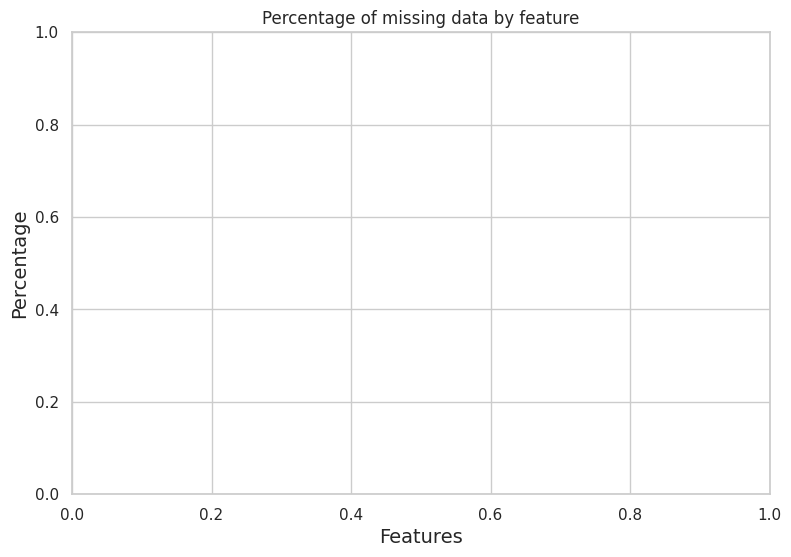

In [19]:
plt.figure(figsize=(9,6))
sns.set(style="whitegrid")
sns.barplot(x=missing_data.index, y=missing_data['Percentage'], data = missing_data)
plt.title('Percentage of missing data by feature')
plt.xlabel('Features', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.show()

In [20]:
# Step 2: Remove columns with >50% missing value
threshold = 0.5

missing_percentage = df.isnull().mean()

columns_to_drop = missing_percentage[missing_percentage > threshold].index

print("\nColumns removed:", list(columns_to_drop))

df = df.drop(columns=columns_to_drop)

# Step 3: Fill remaining missing values
for column in df.columns:

    # Numerical columns
    if df[column].dtype in ["int64", "float64"]:
        df[column].fillna(df[column].median(), inplace=True)

    # Categorical columns
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

# Step 4: Verify again
print("\nMissing values after handling:\n")
print(df.isnull().sum())


Columns removed: []

Missing values after handling:

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


*Data Distribution*

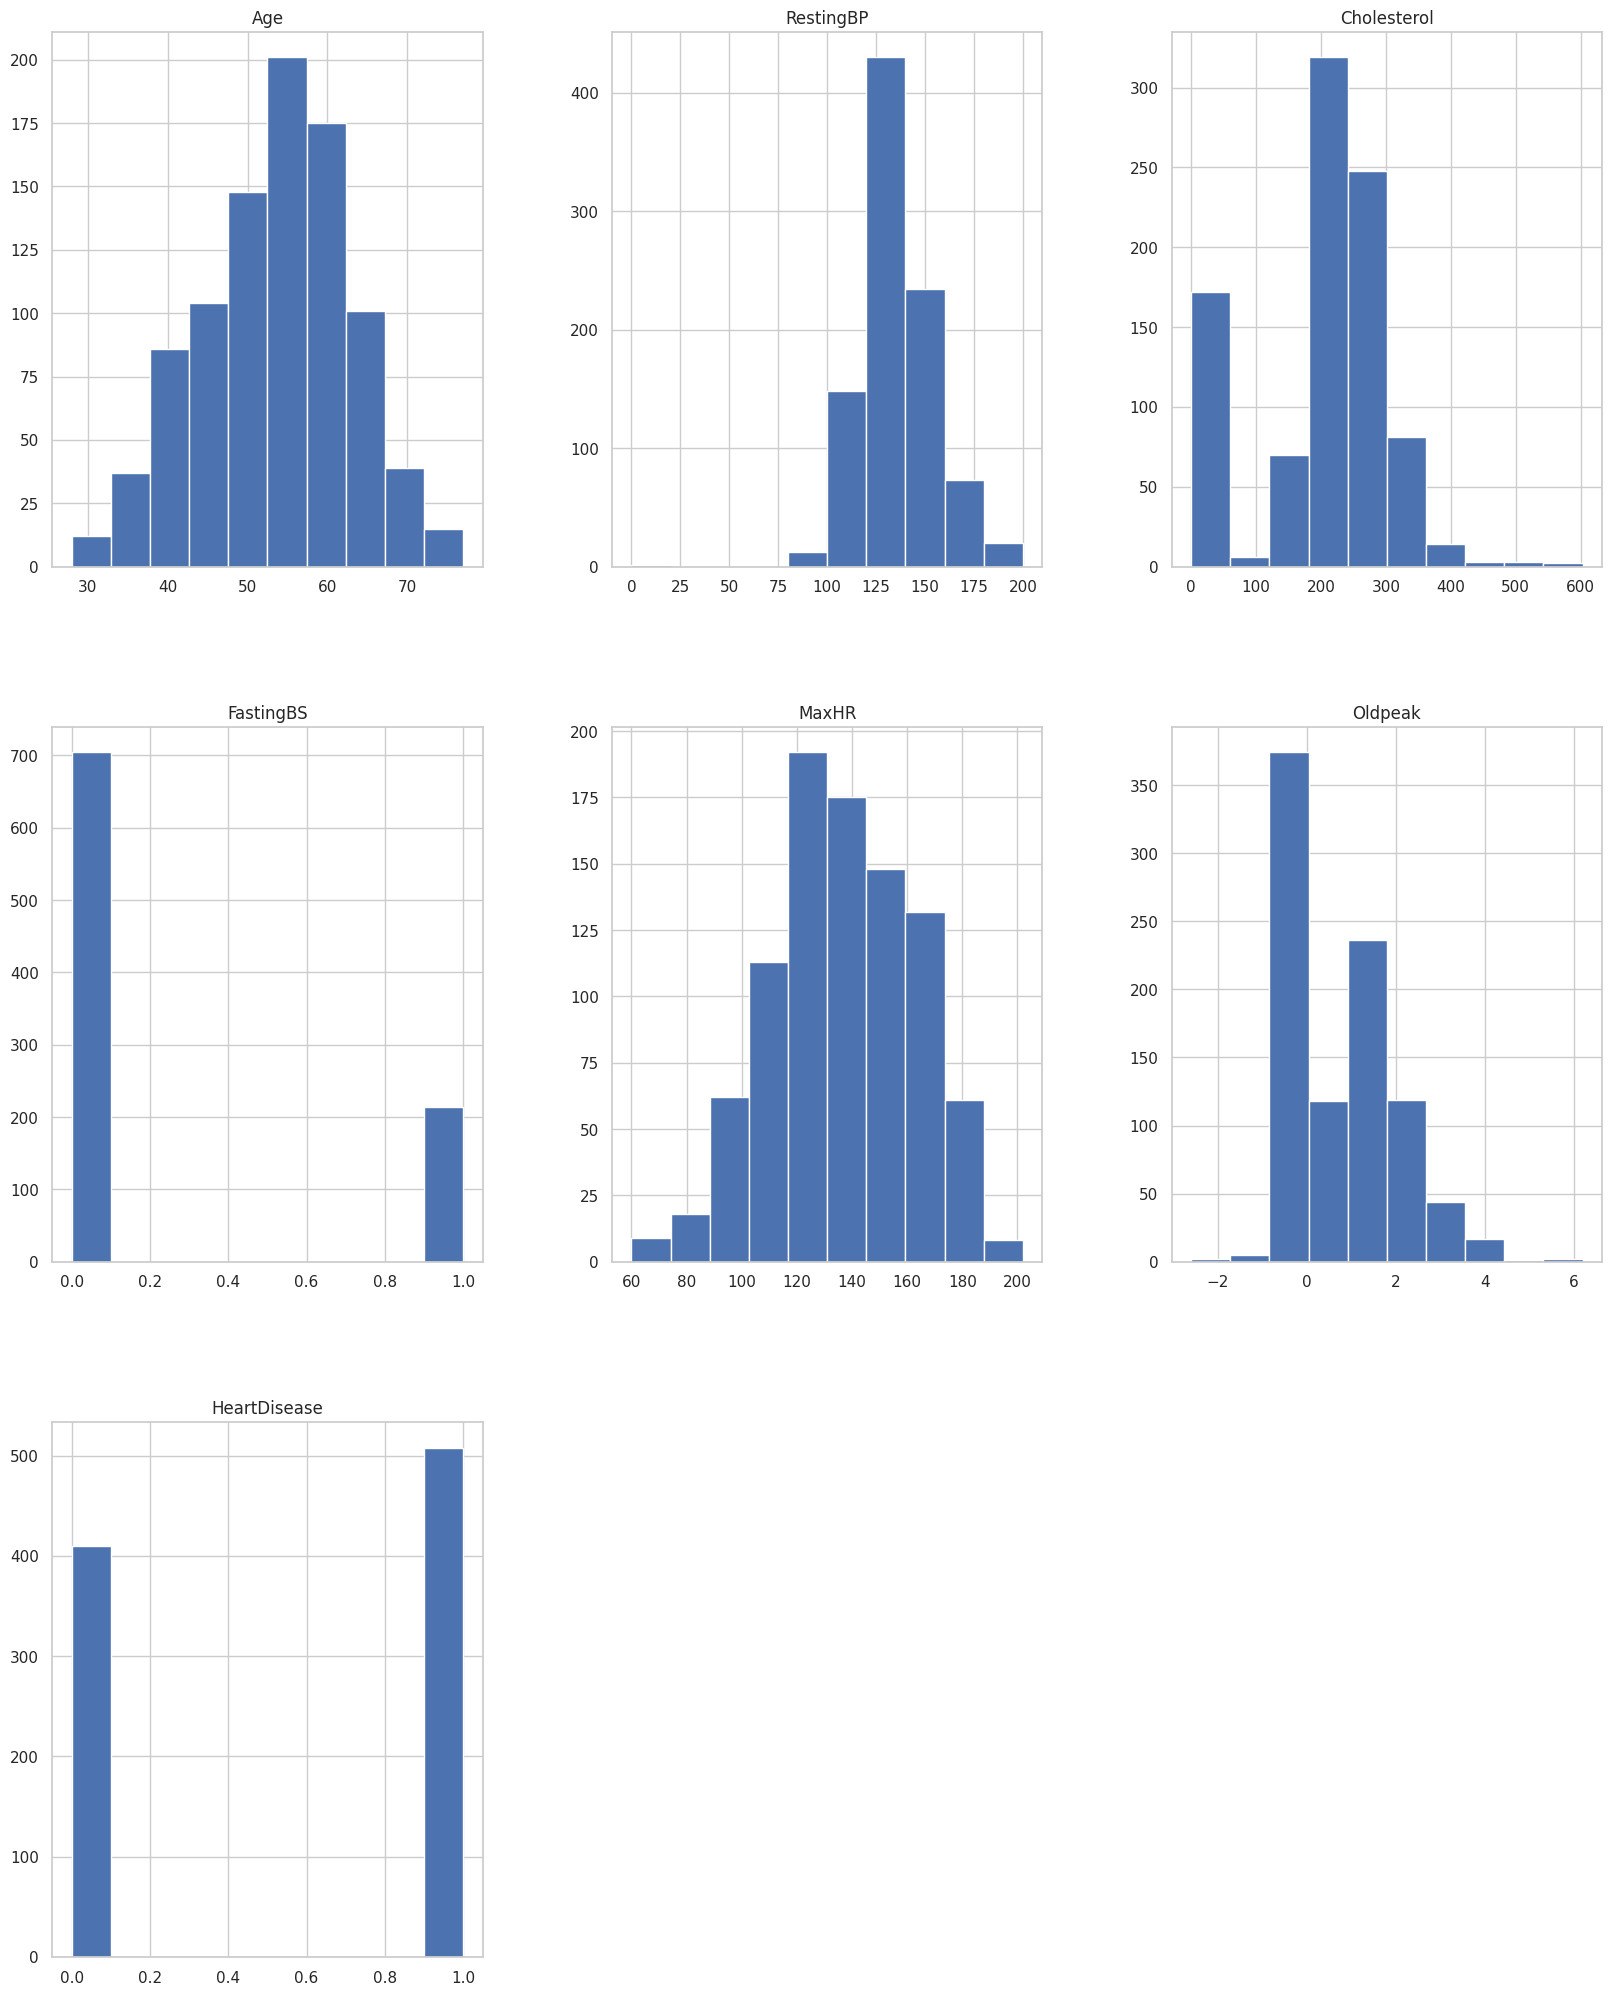

In [21]:
# plot histogram to see the distribution of the data
fig = plt.figure(figsize = (20,25))
ax = fig.gca()
df.hist(ax = ax)
plt.show()

#to check the balancing

*People with or without risk*

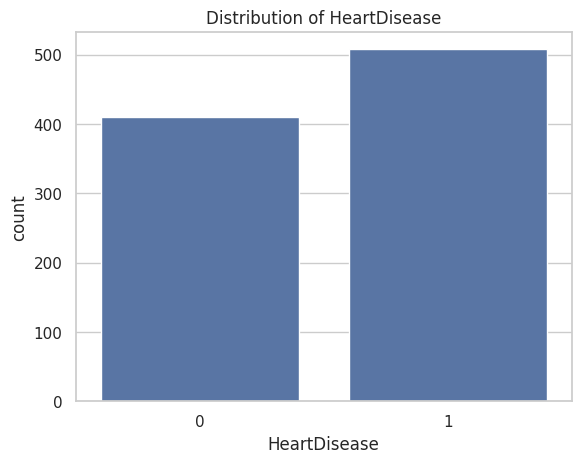

Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [22]:
target_col = 'HeartDisease' #change according to dataset


sns.countplot(x=target_col, data=df)
plt.title(f"Distribution of {target_col}")
plt.show()

cases = df[target_col].value_counts()

print(f"Class distribution:\n{cases}")

***Features and Heart attack Risk***

In [23]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


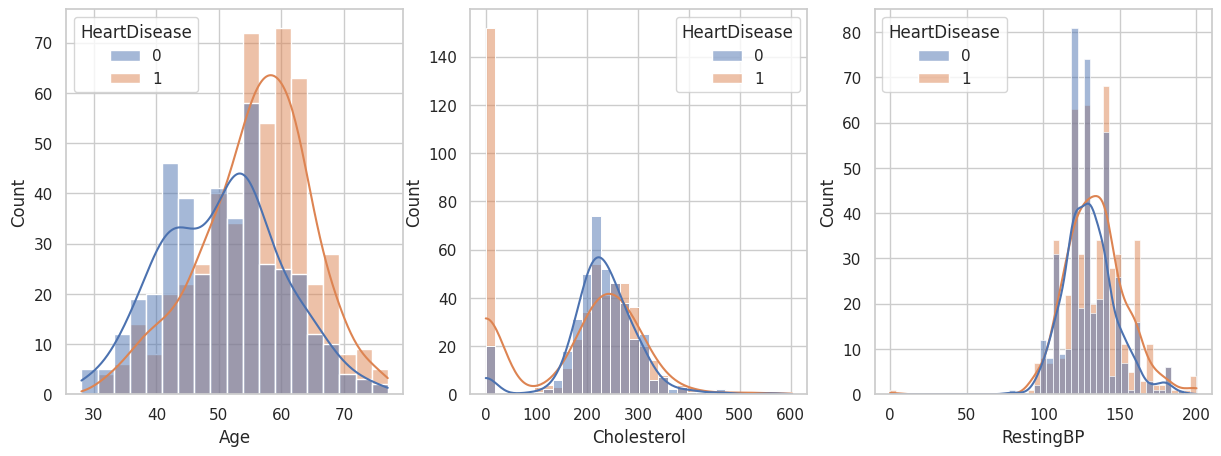

In [24]:
features = ['Age','Cholesterol','RestingBP']
target = 'HeartDisease'

plt.figure(figsize=(20,5))

for i, feature in enumerate(features):
    plt.subplot(1,4,i+1)
    sns.histplot(data=df, x=feature, hue=target, kde=True)

plt.show()

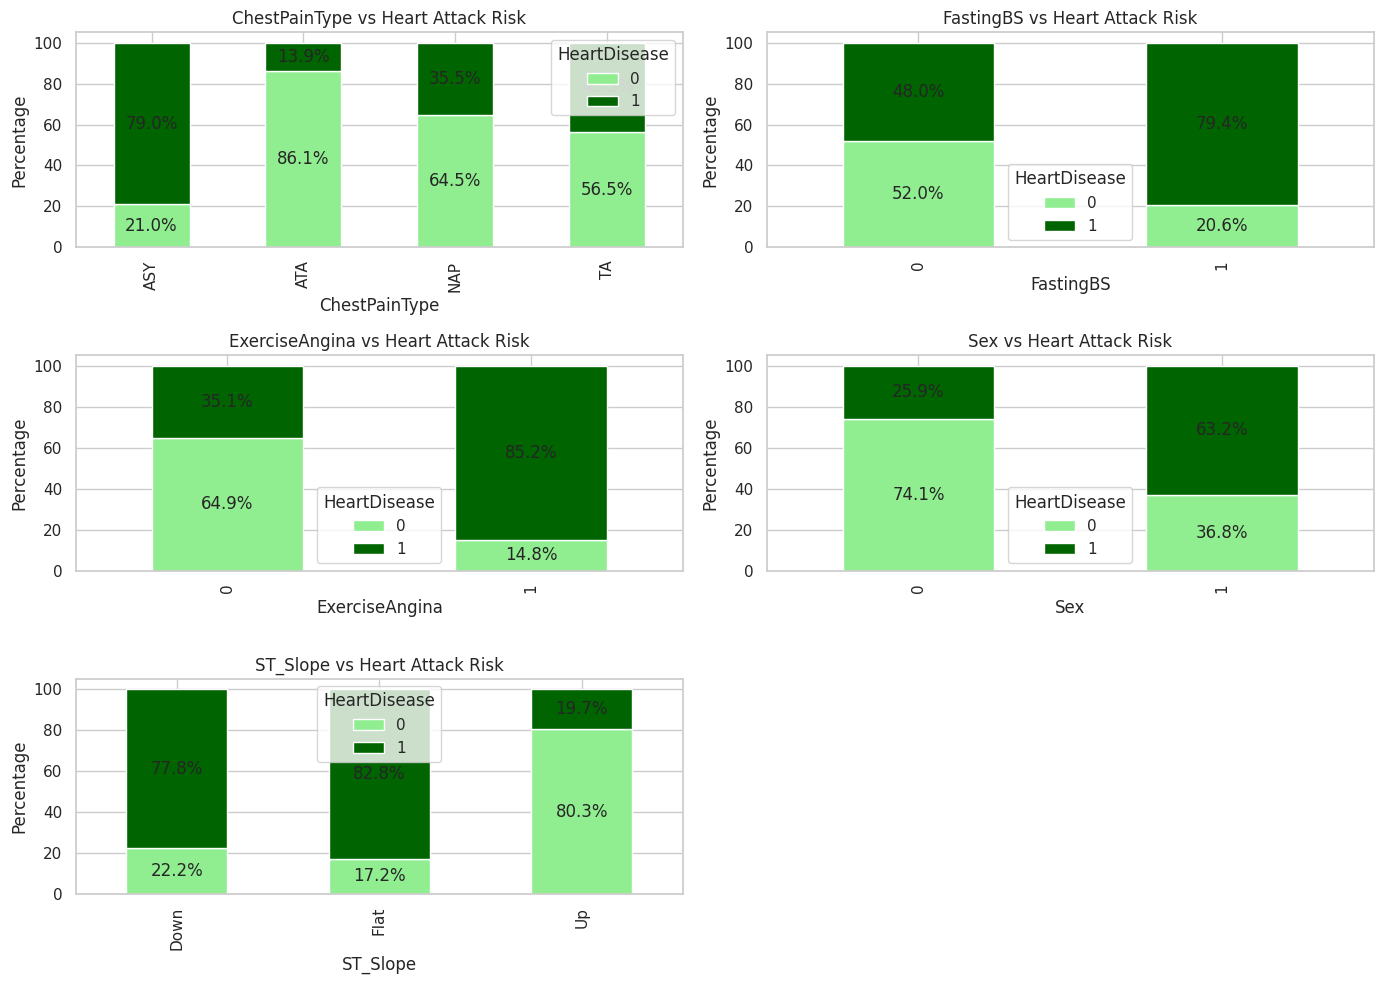

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Re-load the original dataset for this specific visualization
# This ensures we work with the original categorical columns before one-hot encoding
temp_df_for_plot = pd.read_csv('heart.csv')

# Apply Label Encoding for binary categorical columns that were encoded earlier
le = LabelEncoder()
temp_df_for_plot['Sex'] = le.fit_transform(temp_df_for_plot['Sex']) # M/F -> 1/0
temp_df_for_plot['ExerciseAngina'] = le.fit_transform(temp_df_for_plot['ExerciseAngina']) # Y/N -> 1/0

features = [
    'ChestPainType',
    'FastingBS', # This is already numeric (0/1) but was treated as categorical in previous analysis, so keep it for consistency.
    'ExerciseAngina',
    'Sex',
    'ST_Slope'

]

target = 'HeartDisease'

plt.figure(figsize=(14,10))

for i, feature in enumerate(features):

    plt.subplot(3,2,i+1)

    # create crosstab using the temporary DataFrame
    data = pd.crosstab(temp_df_for_plot[feature], temp_df_for_plot[target])

    # convert to percentage
    data_percent = data.div(data.sum(axis=1), axis=0) * 100

    # plot stacked bar
    data_percent.plot(
        kind='bar',
        stacked=True,
        color=['#90EE90','#006400'],   # No Risk, Risk
        ax=plt.gca()
    )

    plt.title(f"{feature} vs Heart Attack Risk")
    plt.ylabel("Percentage")
    plt.xlabel(feature)

    # add percentage labels
    for c in plt.gca().containers:
        labels = [f"{v.get_height():.1f}%" if v.get_height()>0 else "" for v in c]
        plt.bar_label(c, labels=labels, label_type='center')

plt.tight_layout()
plt.show()

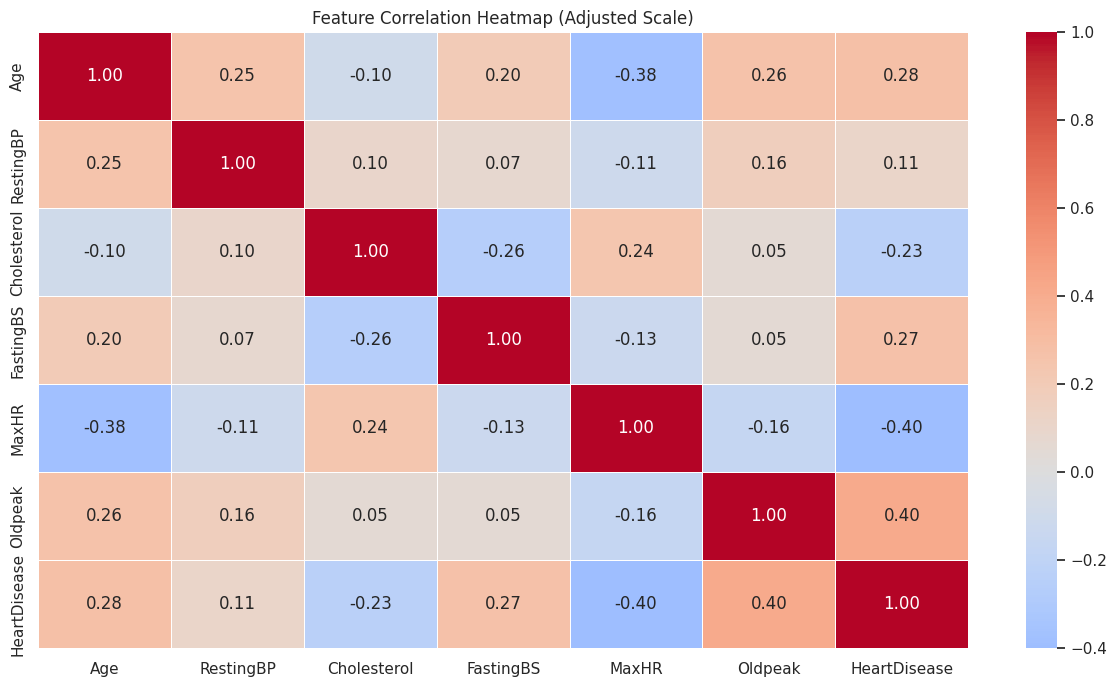

In [26]:
plt.figure(figsize=(15,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    # vmin=-0.1, vmax=0.1,
    center=0
)

plt.title("Feature Correlation Heatmap (Adjusted Scale)")
plt.show()

In [27]:
!pip install boruta


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from boruta import BorutaPy

In [29]:
# Step 1: Prepare data
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Step 2: Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Step 3: Convert to numpy
X = X.values
y = y.values

# Step 4: Define model
forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 5: Apply Boruta
feat_selector = BorutaPy(forest, n_estimators='auto', verbose=2)

feat_selector.fit(X, y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	9 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	10 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	11 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	12 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	13 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	14 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	15 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration: 	16 / 100
Confirmed: 	7
Tentative: 	2
Rejected: 	6
Iteration:

,estimator,RandomForestC...x7EA860B4CD40)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M...0x7EA860B4CD40
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",40


In [30]:
# Get feature names
feature_names = pd.get_dummies(df.drop(columns=['HeartDisease']), drop_first=True).columns

# Get selected features
important_features = feature_names[feat_selector.support_]

print("Important Features:")
print(important_features)

Important Features:
Index(['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')


In [31]:
X_selected = pd.DataFrame(X, columns=feature_names)[important_features]

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8097826086956522


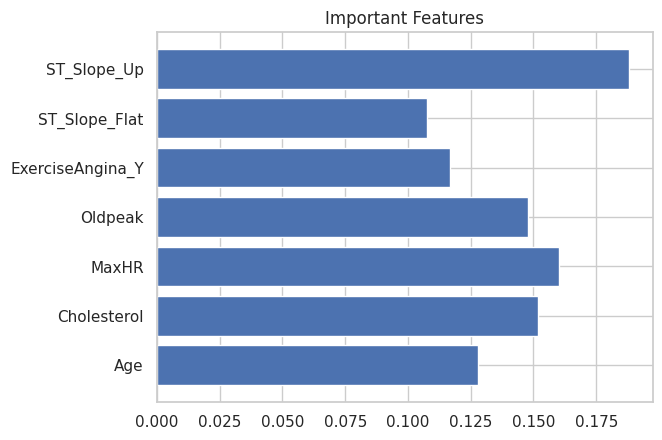

In [33]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(important_features, importances)
plt.title("Important Features")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from boruta import BorutaPy

# Step 1: Train full model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_full = RandomForestClassifier(n_estimators=100, random_state=42)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
print("Accuracy with all features:", accuracy_full)

# Step 2: Apply Boruta
rf = RandomForestClassifier(n_estimators=100, random_state=42)
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)
boruta_selector.fit(X, y)

# Step 3: Get Boruta-selected features
selected_features = feature_names[boruta_selector.support_]
X_selected = pd.DataFrame(X, columns=feature_names)[selected_features]

# Step 4: Train model on Boruta-selected features
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
model_sel = RandomForestClassifier(n_estimators=100, random_state=42)
model_sel.fit(X_train_sel, y_train_sel)
y_pred_sel = model_sel.predict(X_test_sel)
accuracy_sel = accuracy_score(y_test_sel, y_pred_sel)
print("Accuracy with Boruta-selected features:", accuracy_sel)

# Step 5: Decide whether to reduce features (1% tolerance)
tolerance = 0.01  # 1% drop allowed
if accuracy_sel >= accuracy_full:
    print("\n Feature reduction successful! Use Boruta-selected features:")
    print(list(selected_features))
    print("Accuracy:", accuracy_sel)
elif (accuracy_full - accuracy_sel) <= tolerance:
    print("\n Slight accuracy drop (≤1%). You can still use reduced features if efficiency matters:")
    print(list(selected_features))
    print("Accuracy:", accuracy_sel)
else:
    print("\n Accuracy dropped too much. Keep all features.")
    print("Use all features. Accuracy:", accuracy_full)

Accuracy with all features: 0.875
Accuracy with Boruta-selected features: 0.8097826086956522

 Accuracy dropped too much. Keep all features.
Use all features. Accuracy: 0.875


In [35]:
# Using the chosen features
final_X = X_selected if (accuracy_sel >= accuracy_full or (accuracy_full - accuracy_sel) <= 0.01) else pd.DataFrame(X, columns=feature_names)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(final_X, y, test_size=0.2, random_state=42)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_final, y_train_final)

y_pred_final = final_model.predict(X_test_final)
final_accuracy = accuracy_score(y_test_final, y_pred_final)
print(" Final Model Accuracy:", final_accuracy)
print(" Final Features Used:", list(final_X.columns))

 Final Model Accuracy: 0.875
 Final Features Used: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [36]:
import statsmodels.api as sm

In [37]:
X_top = final_X
y = df['HeartDisease']

In [38]:
print(X_top.dtypes)
print(y.dtypes)

Age                  object
RestingBP            object
Cholesterol          object
FastingBS            object
MaxHR                object
Oldpeak              object
Sex_M                object
ChestPainType_ATA    object
ChestPainType_NAP    object
ChestPainType_TA     object
RestingECG_Normal    object
RestingECG_ST        object
ExerciseAngina_Y     object
ST_Slope_Flat        object
ST_Slope_Up          object
dtype: object
int64


In [39]:
X_top = X_top.astype(float)
y = y.astype(float)

In [40]:
import statsmodels.api as sm

X_top = sm.add_constant(X_top)

In [41]:
res = sm.Logit(y,X_top).fit()
res.summary()

Optimization terminated successfully.
         Current function value: 0.323630
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           HeartDisease   No. Observations:                  918
Model:                          Logit   Df Residuals:                      902
Method:                           MLE   Df Model:                           15
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.5292
Time:                        16:06:33   Log-Likelihood:                -297.09
converged:                       True   LL-Null:                       -631.07
Covariance Type:            nonrobust   LLR p-value:                1.250e-132
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.1637      1.416     -0.822      0.411      -3.939       1.612
Age                   0.0166      0.013      1.254      0.210      -0.009       0.042
RestingBP             0.0042      0.006      0.698      0.485      -0.008       0.016
Cholesterol          -0.0041      0.001     -3.785      0.000      -0.006      -0.002
FastingBS             1.1365      0.275      4.133      0.000       0.597       1.675
MaxHR                -0.0043      0.005     -0.854      0.393      -0.014       0.006
Oldpeak               0.3806      0.118      3.213      0.001       0.148       0.613
Sex_M                 1.4665      0.280      5.241      0.000       0.918       2.015
ChestPainType_ATA    -1.8303      0.326     -5.609      0.000      -2.470      -1.191
ChestPainType_NAP    -1.6857      0.266     -6.337      0.000      -2.207      -1.164
ChestPainType_TA     -1.4884      0.433     -3.441      0.001      -2.336      -0.641
RestingECG_Normal    -0.1770      0.272     -0.651      0.515      -0.710       0.356
RestingECG_ST        -0.2685      0.350     -0.767      0.443      -0.955       0.417
ExerciseAngina_Y      0.9003      0.245      3.682      0.000       0.421       1.380
ST_Slope_Flat         1.4539      0.429      3.388      0.001       0.613       2.295
ST_Slope_Up          -0.9941      0.450     -2.208      0.027      -1.876      -0.112
=====================================================================================
"""

In [42]:
from sklearn.metrics import accuracy_score, recall_score

y_pred = final_model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("Recall:", recall_score(y_test_final, y_pred))

Accuracy: 0.875
Recall: 0.8878504672897196


In [43]:
import numpy as np
import pandas as pd

def analyze_logistic_model(res, alpha=0.05):
    """
    res : fitted logistic regression model (statsmodels)
    alpha : significance level (default 0.05 for 95% CI)
    """

    # Get parameters and confidence intervals
    params = res.params
    conf = res.conf_int(alpha=alpha)

    # Rename columns
    conf.columns = ['lower', 'upper']

    # Add odds ratio
    conf['odds_ratio'] = params

    # Convert to exponent (important!)
    conf_exp = np.exp(conf)

    # Lists to store features
    risk_increase = []
    risk_decrease = []
    no_effect = []

    # Classification logic
    for feature in conf_exp.index:
        lower = conf_exp.loc[feature, 'lower']
        upper = conf_exp.loc[feature, 'upper']
        odds = conf_exp.loc[feature, 'odds_ratio']

        if lower > 1:
            risk_increase.append(feature)
        elif upper < 1:
            risk_decrease.append(feature)
        else:
            no_effect.append(feature)

    return conf_exp, risk_increase, risk_decrease, no_effect

In [44]:
conf_table, inc, dec, no_eff = analyze_logistic_model(res)

print("Odds Ratio Table:\n", conf_table)

print("\n Risk Increasing Features:", inc)
print(" Risk Decreasing Features:", dec)
print(" No Significant Effect:", no_eff)

Odds Ratio Table:
                       lower     upper  odds_ratio
const              0.019468  5.011120    0.312342
Age                0.990728  1.043328    1.016688
RestingBP          0.992444  1.016100    1.004202
Cholesterol        0.993774  0.998018    0.995894
FastingBS          1.817558  5.341309    3.115789
MaxHR              0.985968  1.005571    0.995721
Oldpeak            1.160040  1.845651    1.463226
Sex_M              2.504312  7.500286    4.333942
ChestPainType_ATA  0.084601  0.303988    0.160367
ChestPainType_NAP  0.110026  0.312132    0.185318
ChestPainType_TA   0.096693  0.526994    0.225735
RestingECG_Normal  0.491646  1.427507    0.837752
RestingECG_ST      0.384976  1.518133    0.764490
ExerciseAngina_Y   1.523570  3.973026    2.460321
ST_Slope_Flat      1.845792  9.923393    4.279780
ST_Slope_Up        0.153130  0.894283    0.370056

 Risk Increasing Features: ['FastingBS', 'Oldpeak', 'Sex_M', 'ExerciseAngina_Y', 'ST_Slope_Flat']
 Risk Decreasing Features: ['Cho

Imbalance check

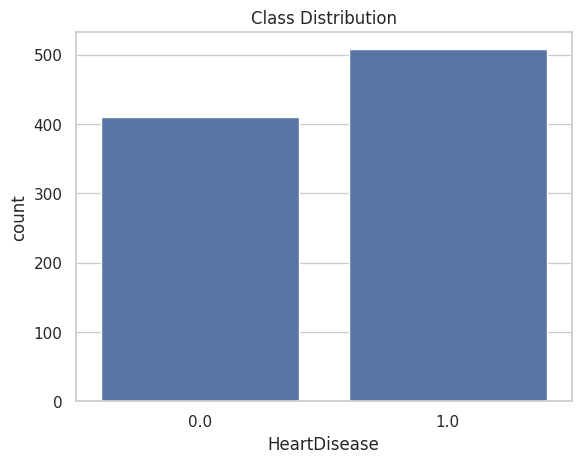

HeartDisease
1.0    0.553377
0.0    0.446623
Name: proportion, dtype: float64


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

y = df['HeartDisease'] # Define y
y = y.astype(float) # Convert y to float, consistent with previous steps

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

print(y.value_counts(normalize=True))

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    final_X, y, test_size=0.2, stratify=y, random_state=42
)

Handling imbalance using SMOTE (Synthetic Minority Oversampling Technique)

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())

Before: HeartDisease
1.0    406
0.0    328
Name: count, dtype: int64
After: HeartDisease
1.0    406
0.0    406
Name: count, dtype: int64


In [48]:
# Baseline (no balancing)
X_train_base = X_train.copy()
y_train_base = y_train.copy()

class weight model

In [49]:
from sklearn.ensemble import RandomForestClassifier

model_weight = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

model_weight.fit(X_train_base, y_train_base)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

SMOTE model

In [50]:
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Hybrid model (class weights + smote)

In [51]:
model_hybrid = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

model_hybrid.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluation for all models



In [52]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def get_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    precision_0 = precision_score(y_test, y_pred, pos_label=0)
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall_0": recall_0,
        "Recall_1": recall_1,
        "Precision_0": precision_0,
        "Precision_1": precision_1,
        "F1_0": f1_0,
        "F1_1": f1_1
    }

# Evaluate models
results = []

probs_weight = model_weight.predict_proba(X_test)[:, 1]
results.append(get_metrics(model_weight, X_test, y_test, "Class Weight"))

probs_smote = model_smote.predict_proba(X_test)[:, 1]
results.append(get_metrics(model_smote, X_test, y_test, "SMOTE"))

probs_hybrid = model_hybrid.predict_proba(X_test)[:, 1]
results.append(get_metrics(model_hybrid, X_test, y_test, "Hybrid (SMOTE + Class Weight)"))

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Recall_1", ascending=False))

                           Model  Accuracy  Recall_0  Recall_1  Precision_0  \
0                   Class Weight  0.891304  0.853659  0.921569     0.897436   
1                          SMOTE  0.896739  0.865854  0.921569     0.898734   
2  Hybrid (SMOTE + Class Weight)  0.896739  0.865854  0.921569     0.898734   

   Precision_1      F1_0      F1_1  
0     0.886792  0.875000  0.903846  
1     0.895238  0.881988  0.908213  
2     0.895238  0.881988  0.908213  


In [53]:
best_row = results_df.sort_values(by="Recall_1", ascending=False).iloc[0]
print("Best Combination:\n", best_row)

Best Combination:
 Model          Class Weight
Accuracy           0.891304
Recall_0           0.853659
Recall_1           0.921569
Precision_0        0.897436
Precision_1        0.886792
F1_0                  0.875
F1_1               0.903846
Name: 0, dtype: object


In [54]:
if "Hybrid" in best_row["Model"]:
    best_model = model_hybrid
    best_probs = probs_hybrid
    strategy_used = "SMOTE + Class Weight"

elif "SMOTE" in best_row["Model"]:
    best_model = model_smote
    best_probs = probs_smote
    strategy_used = "SMOTE"

else:
    best_model = model_weight
    best_probs = probs_weight
    strategy_used = "Class Weight"

In [55]:
print("\n Final Selected Strategy:", strategy_used)


 Final Selected Strategy: Class Weight


In [56]:
from sklearn.metrics import classification_report

for t in [0.2, 0.3, 0.4]:
    y_pred_custom = (best_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.96      0.56      0.71        82
         1.0       0.74      0.98      0.84       102

    accuracy                           0.79       184
   macro avg       0.85      0.77      0.77       184
weighted avg       0.83      0.79      0.78       184


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.79        82
         1.0       0.79      0.97      0.87       102

    accuracy                           0.84       184
   macro avg       0.87      0.82      0.83       184
weighted avg       0.86      0.84      0.83       184


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.86        82
         1.0       0.85      0.95      0.90       102

    accuracy                           0.88       184
   macro avg       0.89      0.87      0.88       184
weighted avg       0.89   

In [57]:
final_threshold = 0.4

In [58]:
y_pred_final = (best_probs >= final_threshold).astype(int)


 FINAL MODEL PERFORMANCE
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.86        82
         1.0       0.85      0.95      0.90       102

    accuracy                           0.88       184
   macro avg       0.89      0.87      0.88       184
weighted avg       0.89      0.88      0.88       184



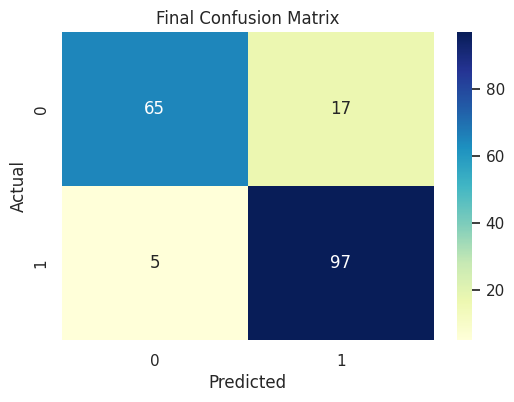

In [59]:
from sklearn.metrics import confusion_matrix

print("\n FINAL MODEL PERFORMANCE")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
if "SMOTE" in strategy_used:
    num_before = y_train.value_counts()
    num_after = y_train_res.value_counts()

    labels = ["Negative Cases", "Positive Cases"]

    plt.figure(figsize=(15,6))

    # BEFORE
    plt.subplot(1,2,1)
    sns.barplot(x=labels, y=list(num_before.values))
    plt.title("Before Balancing")

    # AFTER
    plt.subplot(1,2,2)
    sns.barplot(x=labels, y=list(num_after.values))
    plt.title("After Balancing (SMOTE)")

    plt.show()

In [61]:
print("\n================ FINAL SUMMARY ================")
print("Best Strategy:", strategy_used)
print("Final Threshold:", final_threshold)
print("Model Used: Random Forest")


================ FINAL SUMMARY ================
Best Strategy: Class Weight
Final Threshold: 0.4
Model Used: Random Forest


In [62]:
pip install fairlearn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame
)

from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity,
    EqualizedOdds
)

from fairlearn.postprocessing import ThresholdOptimizer

In [64]:
sensitive = X_test['Sex_M']

In [65]:
bias_baseline = demographic_parity_difference(
    y_test,
    y_pred_final,
    sensitive_features=sensitive
)

print("Baseline Bias:", bias_baseline)

Baseline Bias: 0.41600576784426824


In [66]:
reweigh_model = ExponentiatedGradient(
    RandomForestClassifier(random_state=42),
    constraints=DemographicParity()
)

reweigh_model.fit(
    X_train,
    y_train,
    sensitive_features=X_train['Sex_M']
)

y_pred_reweigh = reweigh_model.predict(X_test)

bias_reweigh = demographic_parity_difference(
    y_test,
    y_pred_reweigh,
    sensitive_features=sensitive
)

print("Reweigh Bias:", bias_reweigh)

Reweigh Bias: 0.15176640230713778


In [67]:
fair_model = ExponentiatedGradient(
    RandomForestClassifier(random_state=42),
    constraints=EqualizedOdds()
)

fair_model.fit(
    X_train,
    y_train,
    sensitive_features=X_train['Sex_M']
)

y_pred_fair = fair_model.predict(X_test)

bias_fair = demographic_parity_difference(
    y_test,
    y_pred_fair,
    sensitive_features=sensitive
)

print("Fair Model Bias:", bias_fair)

Fair Model Bias: 0.47332372025955294


In [68]:
post_model = ThresholdOptimizer(
    estimator=RandomForestClassifier(random_state=42),
    constraints="equalized_odds",
    predict_method="predict_proba"
)

post_model.fit(
    X_train,
    y_train,
    sensitive_features=X_train['Sex_M']
)

y_pred_post = post_model.predict(
    X_test,
    sensitive_features=X_test['Sex_M']
)

bias_post = demographic_parity_difference(
    y_test,
    y_pred_post,
    sensitive_features=sensitive
)

print("Post Processing Bias:", bias_post)

Post Processing Bias: 0.47332372025955294


In [69]:
X_train_nogender = X_train_res.drop(columns=['Sex_M'])
X_test_nogender = X_test.drop(columns=['Sex_M'])

model_nogender = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model_nogender.fit(X_train_nogender, y_train_res)

y_pred_nogender = model_nogender.predict(X_test_nogender)

In [70]:
bias_nogender = demographic_parity_difference(
    y_test,
    y_pred_nogender,
    sensitive_features=X_test['Sex_M']
)

print("No Gender Bias:", bias_nogender)

No Gender Bias: 0.28226387887527044


In [71]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Reweigh",
        "Fair Model",
        "Threshold Optimizer",
        "No Gender Bias"
    ],
    "Bias": [
        bias_baseline,
        bias_reweigh,
        bias_fair,
        bias_post,
        bias_nogender
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_final),
        accuracy_score(y_test, y_pred_reweigh),
        accuracy_score(y_test, y_pred_fair),
        accuracy_score(y_test, y_pred_post),
        accuracy_score(y_test, y_pred_nogender)
    ],
     "Recall": [
        recall_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_reweigh),
        recall_score(y_test, y_pred_fair),
        recall_score(y_test, y_pred_post),
        recall_score(y_test, y_pred_nogender)
    ]
})

print(results)

                 Model      Bias  Accuracy    Recall
0             Baseline  0.416006  0.880435  0.950980
1              Reweigh  0.151766  0.809783  0.911765
2           Fair Model  0.473324  0.875000  0.892157
3  Threshold Optimizer  0.473324  0.875000  0.892157
4       No Gender Bias  0.282264  0.842391  0.892157


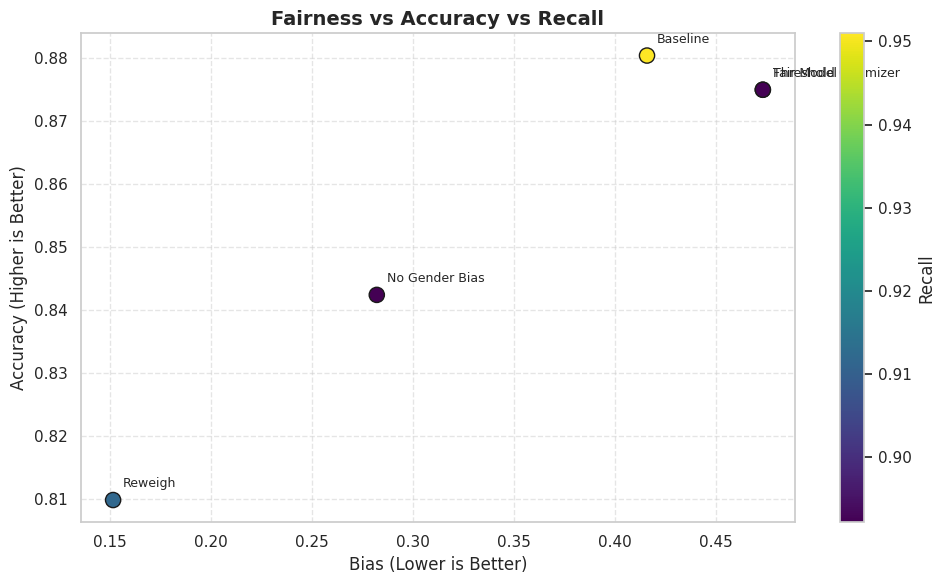

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Scatter plot: Bias vs Accuracy, with Recall as color
scatter = plt.scatter(
    results["Bias"],
    results["Accuracy"],
    c=results["Recall"],       # Recall determines color
    cmap="viridis",            # Color map
    s=120,
    edgecolor='k'
)

# Annotate points with model names
for i in range(len(results)):
    plt.text(
        results["Bias"][i] + 0.005,
        results["Accuracy"][i] + 0.002,
        results["Model"][i],
        fontsize=9
    )

# Labels
plt.xlabel("Bias (Lower is Better)", fontsize=12)
plt.ylabel("Accuracy (Higher is Better)", fontsize=12)
plt.title("Fairness vs Accuracy vs Recall", fontsize=14, fontweight="bold")

# Colorbar for Recall
cbar = plt.colorbar(scatter)
cbar.set_label("Recall", fontsize=12)

# Grid and layout
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

In [73]:
X_train_res, y_train_res   # SMOTE / Hybrid data
X_test, y_test             # test data

(    Age RestingBP Cholesterol FastingBS MaxHR Oldpeak  Sex_M  \
 356  46       115           0         0   113     1.5   True   
 763  58       132         224         0   173     3.2   True   
 817  60       125         258         0   141     2.8   True   
 735  49       120         188         0   139     2.0   True   
 892  39       138         220         0   152     0.0  False   
 ..   ..       ...         ...       ...   ...     ...    ...   
 52   45       140         224         1   122     0.0   True   
 752  56       125         249         1   144     1.2   True   
 492  49       130           0         0   145     3.0   True   
 622  59       110         239         0   142     1.2   True   
 316  57       105           0         1   148     0.3   True   
 
     ChestPainType_ATA ChestPainType_NAP ChestPainType_TA RestingECG_Normal  \
 356             False             False            False              True   
 763             False              True            False   

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve

In [75]:
params = {
    'penalty': ['l1','l2'],
    'C': [0.01,0.1,1,10,100],
    'class_weight': ['balanced', None]
}

log_clf = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid=params, cv=5)

In [76]:
log_clf.fit(X_train_res, y_train_res)

log_clf.best_params_

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}

In [77]:
log_pred = log_clf.predict(X_test)

Logistic Regression Accuracy: 89.13%


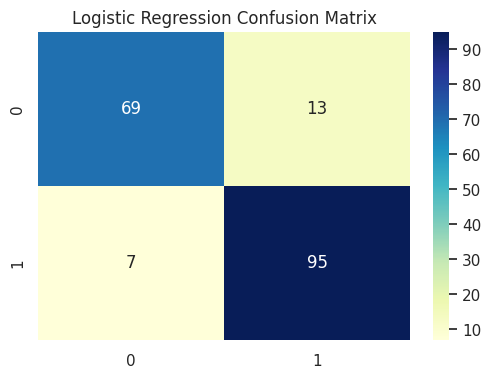

In [78]:
log_acc = accuracy_score(y_test, log_pred)
print(f"Logistic Regression Accuracy: {round(log_acc*100,2)}%")

cm = confusion_matrix(y_test, log_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [79]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87        82
         1.0       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



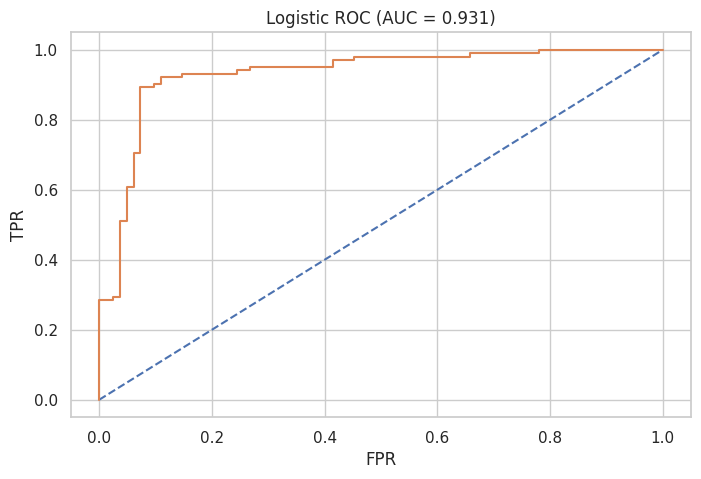

In [80]:
log_probs = log_clf.predict_proba(X_test)[:,1]

log_auc = roc_auc_score(y_test, log_probs)

fpr, tpr, thresholds = roc_curve(y_test, log_probs)

plt.figure(figsize=(8,5))
plt.plot([0,1],[0,1],'--')
plt.plot(fpr, tpr)
plt.title(f"Logistic ROC (AUC = {round(log_auc,3)})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [81]:
for t in [0.2,0.3,0.4]:
    y_pred_custom = (log_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.92      0.71      0.80        82
         1.0       0.80      0.95      0.87       102

    accuracy                           0.84       184
   macro avg       0.86      0.83      0.83       184
weighted avg       0.85      0.84      0.84       184


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.90      0.79      0.84        82
         1.0       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85        82
         1.0       0.86      0.93      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88   

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
params = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2,5,10],
    'class_weight': ['balanced', None]
}

dt_clf = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=params, cv=5)

In [84]:
dt_clf.fit(X_train_res, y_train_res)

dt_clf.best_params_

{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10}

In [85]:
dt_pred = dt_clf.predict(X_test)

Decision Tree Accuracy: 80.98%


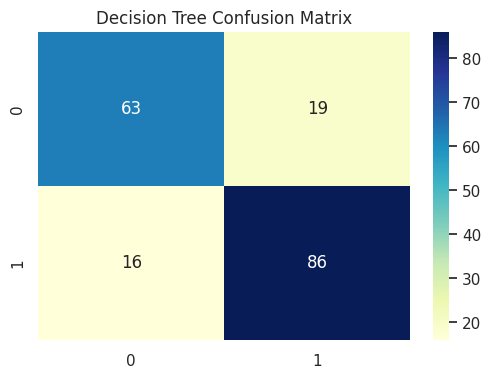

In [86]:
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {round(dt_acc*100,2)}%")

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [87]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.77      0.78        82
         1.0       0.82      0.84      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



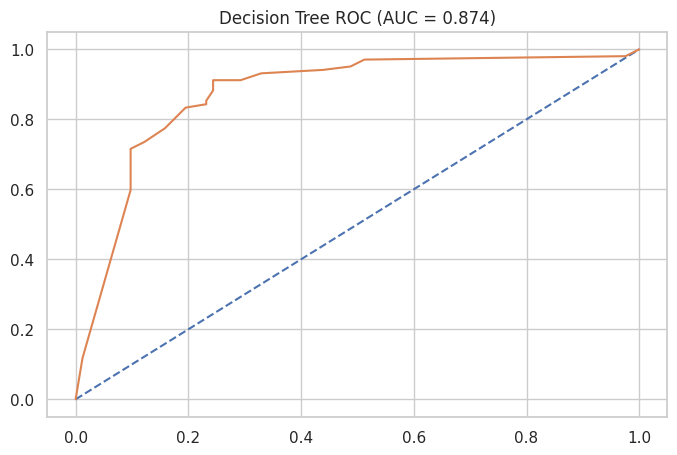

In [88]:
dt_probs = dt_clf.predict_proba(X_test)[:,1]

dt_auc = roc_auc_score(y_test, dt_probs)

fpr, tpr, thresholds = roc_curve(y_test, dt_probs)

plt.figure(figsize=(8,5))
plt.plot([0,1],[0,1],'--')
plt.plot(fpr, tpr)
plt.title(f"Decision Tree ROC (AUC = {round(dt_auc,3)})")
plt.show()

In [89]:
for t in [0.2,0.3,0.4]:
    y_pred_custom = (dt_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.87      0.71      0.78        82
         1.0       0.79      0.91      0.85       102

    accuracy                           0.82       184
   macro avg       0.83      0.81      0.81       184
weighted avg       0.83      0.82      0.82       184


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.87      0.76      0.81        82
         1.0       0.82      0.91      0.87       102

    accuracy                           0.84       184
   macro avg       0.85      0.83      0.84       184
weighted avg       0.85      0.84      0.84       184


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.84      0.76      0.79        82
         1.0       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83   

In [90]:
from sklearn.neighbors import KNeighborsClassifier

In [91]:
params = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

knn_clf = GridSearchCV(KNeighborsClassifier(), param_grid=params, cv=5)

In [92]:
knn_clf.fit(X_train_res, y_train_res)

knn_clf.best_params_

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

In [93]:
knn_pred = knn_clf.predict(X_test)

KNN Accuracy: 70.65%


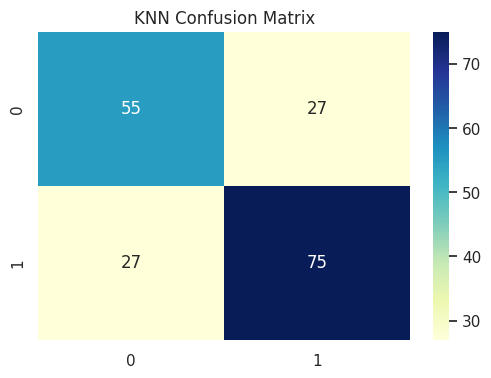

In [94]:
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {round(knn_acc*100,2)}%")

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.title("KNN Confusion Matrix")
plt.show()

In [95]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.67      0.67        82
         1.0       0.74      0.74      0.74       102

    accuracy                           0.71       184
   macro avg       0.70      0.70      0.70       184
weighted avg       0.71      0.71      0.71       184



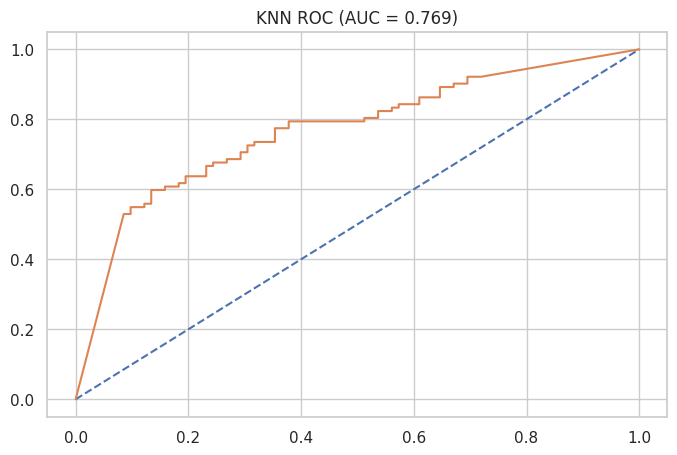

In [96]:
knn_probs = knn_clf.predict_proba(X_test)[:,1]

knn_auc = roc_auc_score(y_test, knn_probs)

fpr, tpr, thresholds = roc_curve(y_test, knn_probs)

plt.figure(figsize=(8,5))
plt.plot([0,1],[0,1],'--')
plt.plot(fpr, tpr)
plt.title(f"KNN ROC (AUC = {round(knn_auc,3)})")
plt.show()

In [97]:
for t in [0.2,0.3,0.4]:
    y_pred_custom = (knn_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.2
              precision    recall  f1-score   support

         0.0       0.75      0.29      0.42        82
         1.0       0.62      0.92      0.74       102

    accuracy                           0.64       184
   macro avg       0.68      0.61      0.58       184
weighted avg       0.68      0.64      0.60       184


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.72      0.35      0.48        82
         1.0       0.63      0.89      0.74       102

    accuracy                           0.65       184
   macro avg       0.68      0.62      0.61       184
weighted avg       0.67      0.65      0.62       184


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.69      0.65      0.67        82
         1.0       0.73      0.76      0.75       102

    accuracy                           0.71       184
   macro avg       0.71      0.71      0.71       184
weighted avg       0.71   

In [98]:
print("AUC Scores:")
print("Logistic:", log_auc)
print("Decision Tree:", dt_auc)
print("KNN:", knn_auc)

AUC Scores:
Logistic: 0.9312529890004781
Decision Tree: 0.8739837398373984
KNN: 0.768651362984218


In [99]:
import pandas as pd
from sklearn.metrics import f1_score

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],

    "Accuracy": [
        log_acc,
        dt_acc,
        knn_acc
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, knn_pred)
    ],

    "ROC-AUC": [
        log_auc,
        dt_auc,
        knn_auc
    ]
})

print(final_results)

                 Model  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.891304  0.904762  0.931253
1        Decision Tree  0.809783  0.830918  0.873984
2                  KNN  0.706522  0.735294  0.768651


In [100]:
from sklearn.metrics import classification_report, recall_score

def get_recall(y_true, y_pred):
    # Using recall_score directly for the positive class (label 1)
    return recall_score(y_true.astype(int), y_pred.astype(int), pos_label=1)

final_results["Recall (Disease)"] = [
    get_recall(y_test, log_pred),
    get_recall(y_test, dt_pred),
    get_recall(y_test, knn_pred)
]

print(final_results)

                 Model  Accuracy  F1 Score   ROC-AUC  Recall (Disease)
0  Logistic Regression  0.891304  0.904762  0.931253          0.931373
1        Decision Tree  0.809783  0.830918  0.873984          0.843137
2                  KNN  0.706522  0.735294  0.768651          0.735294


In [101]:
print(classification_report(y_test, log_pred, output_dict=True).keys())

dict_keys(['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg'])


In [102]:
final_results = final_results.sort_values(by="Recall (Disease)", ascending=False)
print(final_results.round(3))

                 Model  Accuracy  F1 Score  ROC-AUC  Recall (Disease)
0  Logistic Regression     0.891     0.905    0.931             0.931
1        Decision Tree     0.810     0.831    0.874             0.843
2                  KNN     0.707     0.735    0.769             0.735


In [103]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))

In [104]:
# Model saved as model.pkl in the workspace